# Синтетика: аппроксимация функций MLP

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Третий тип данных из условия -- **синтетические функции**. 

Здесь истинная функция известна, поэтому влияние архитектуры видно напрямую.

Функции специально подобрал разные по структуре: почти линейная, полиномиальная, периодическая и ступенчатая.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn


SEED = 143
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks" and cwd.parent.name == "hws":
    HWS_DIR = cwd.parent
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEPTHS = [1, 2, 5, 10, 20]
WIDTHS = [8, 16, 32, 64, 128]
EPOCHS = 700
LR = 1e-2
WEIGHT_DECAY = 1e-5

sns.set_theme(style="whitegrid")


In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def f_near_linear(x):  # почти линейна -- aka бейслайн
    return 0.8 * x + 0.15 * np.sin(3 * x)


def f_polynomial(x):  # легенький полиномчик
    return 0.12 * x**3 - 0.45 * x


def f_periodic(x):  # а с периодической что?
    return np.sin(3 * x) + 0.3 * np.cos(7 * x)


def f_heaviside(x):  # гробовая для приближения ступенчатая функция, попила мне крови на Численных Методах в универе
    return np.heaviside(x, 0.5).astype(np.float32)


FUNCTIONS = {
    "near_linear": f_near_linear,
    "polynomial": f_polynomial,
    "periodic": f_periodic,
    "heaviside": f_heaviside,
}


### Почему именно такие функции

- `near_linear` -- sanity check: сложная архитектура здесь почти не нужна;
- `polynomial` -- гладкая нелинейность без осцилляций;
- `periodic` -- много локальных изменений, здесь ожидаю увидеть влияние глубины/ширины;
- `Heaviside` -- ступенечка, _непрерывными функциями ее идеально не приблизить_.


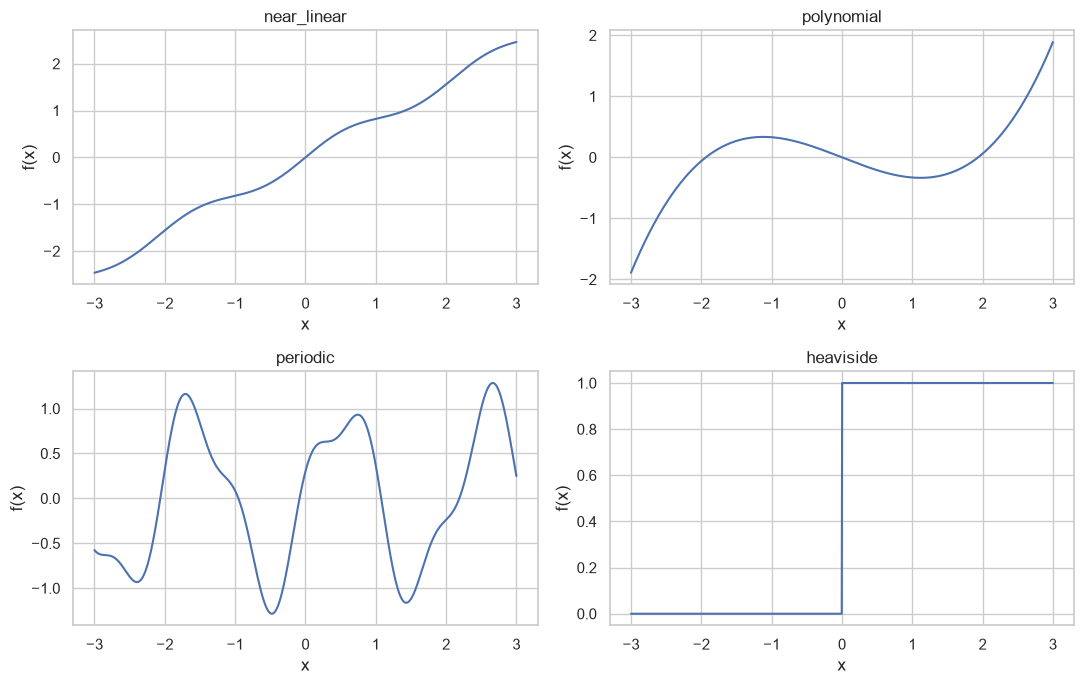

In [3]:
x_plot = np.linspace(-3, 3, 1000, dtype=np.float32)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, function) in zip(axes.ravel(), FUNCTIONS.items()):
    ax.plot(x_plot, function(x_plot))
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "synthetic_functions.png", dpi=170, bbox_inches="tight")
plt.show()


In [4]:
class RegressionMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()
        layers = []
        in_features = 1
        for _ in range(depth):
            layers.extend([nn.Linear(in_features, width), nn.Tanh()])
            in_features = width
        layers.append(nn.Linear(in_features, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_data(function, n_train=500, n_val=250, noise=0.06):
    rng = np.random.default_rng(SEED)
    x = rng.uniform(-3, 3, size=n_train + n_val).astype(np.float32)
    y = function(x).astype(np.float32) + rng.normal(0, noise, size=len(x)).astype(np.float32)

    order = rng.permutation(len(x))
    train_idx, val_idx = order[:n_train], order[n_train:]
    x_test = np.linspace(-3, 3, 1000, dtype=np.float32)

    return (
        torch.from_numpy(x[train_idx, None]).to(DEVICE),
        torch.from_numpy(y[train_idx, None]).to(DEVICE),
        torch.from_numpy(x[val_idx, None]).to(DEVICE),
        torch.from_numpy(y[val_idx, None]).to(DEVICE),
        torch.from_numpy(x_test[:, None]).to(DEVICE),
        torch.from_numpy(function(x_test)[:, None].astype(np.float32)).to(DEVICE),
    )


def fit_regressor(function, depth, width, epochs=EPOCHS):
    set_seed()
    X_train, y_train, X_val, y_val, X_test, y_test = make_data(function)
    model = RegressionMLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        train_prediction = model(X_train)
        train_loss = loss_fn(train_prediction, y_train)
        train_loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 20 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_val), y_val).item()
            history.append({"epoch": epoch, "train_mse": train_loss.item(), "val_mse": val_loss})

    model.eval()
    with torch.no_grad():
        prediction = model(X_test).cpu().numpy().ravel()
        test_mse = loss_fn(model(X_test), y_test).item()

    return model, pd.DataFrame(history), X_test.cpu().numpy().ravel(), prediction, test_mse


## Heatmap width × depth


In [5]:
synthetic_grid = []
for depth in DEPTHS:
    for width in WIDTHS:
        print(f"depth={depth}, width={width}")
        model, history, x_test, prediction, test_mse = fit_regressor(f_periodic, depth, width)
        synthetic_grid.append({
            "function": "periodic",
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "test_mse": test_mse,
        })

synthetic_grid = pd.DataFrame(synthetic_grid)
synthetic_grid.to_csv(OUTPUT_DIR / "synthetic_grid_results.csv", index=False)
synthetic_grid.sort_values("test_mse").head(10)


depth=1, width=8
depth=1, width=16
depth=1, width=32
depth=1, width=64
depth=1, width=128
depth=2, width=8
depth=2, width=16
depth=2, width=32
depth=2, width=64
depth=2, width=128
depth=5, width=8
depth=5, width=16
depth=5, width=32
depth=5, width=64
depth=5, width=128
depth=10, width=8
depth=10, width=16
depth=10, width=32
depth=10, width=64
depth=10, width=128
depth=20, width=8
depth=20, width=16
depth=20, width=32
depth=20, width=64
depth=20, width=128


,function,depth,width,parameters,test_mse
13,periodic,5,64,16833,0.000587
8,periodic,2,64,4353,0.000751
12,periodic,5,32,4321,0.000949
14,periodic,5,128,66433,0.002209
11,periodic,5,16,1137,0.002630
9,periodic,2,128,16897,0.004359
15,periodic,10,8,673,0.012835
7,periodic,2,32,1153,0.012968
10,periodic,5,8,313,0.014825
6,periodic,2,16,321,0.017788


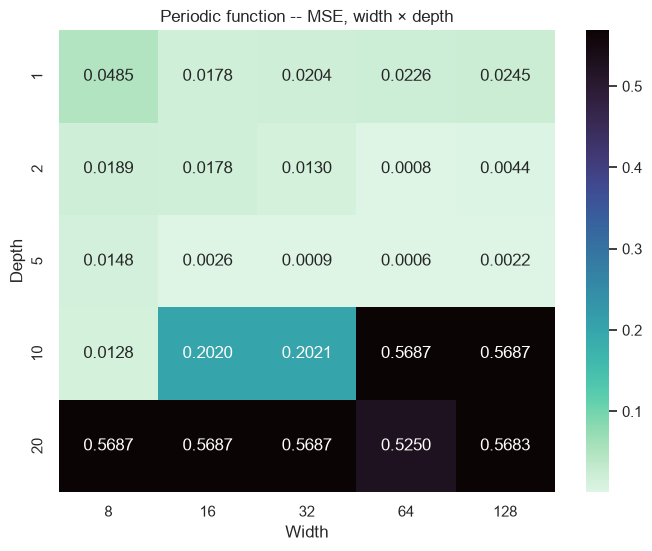

In [6]:
mse_heatmap = synthetic_grid.pivot(index="depth", columns="width", values="test_mse")
plt.figure(figsize=(8, 6))
sns.heatmap(mse_heatmap, annot=True, fmt=".4f", cmap="mako_r")
plt.title("Periodic function -- MSE, width × depth")
plt.xlabel("Width")
plt.ylabel("Depth")
plt.savefig(OUTPUT_DIR / "synthetic_mse_heatmap.png", dpi=170, bbox_inches="tight")
plt.show()


## Shallow vs deep на четырех функциях


In [7]:
COMPARE_CONFIGS = [(1, 128), (5, 64), (20, 32)]
comparison_rows = []
comparison_predictions = {}
comparison_histories = {}

for function_name, function in FUNCTIONS.items():
    for depth, width in COMPARE_CONFIGS:
        model, history, x_test, prediction, test_mse = fit_regressor(function, depth, width)
        comparison_rows.append({
            "function": function_name,
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "test_mse": test_mse,
        })
        comparison_predictions[(function_name, depth, width)] = (x_test, prediction)
        comparison_histories[(function_name, depth, width)] = history

comparison_results = pd.DataFrame(comparison_rows)
comparison_results.to_csv(OUTPUT_DIR / "synthetic_comparison.csv", index=False)
comparison_results


,function,depth,width,parameters,test_mse
0,near_linear,1,128,385,0.001877
1,near_linear,5,64,16833,0.000084
2,near_linear,20,32,20161,2.012371
3,polynomial,1,128,385,0.000471
4,polynomial,5,64,16833,0.000127
5,polynomial,20,32,20161,0.361142
6,periodic,1,128,385,0.024529
7,periodic,5,64,16833,0.000587
8,periodic,20,32,20161,0.568704
9,heaviside,1,128,385,0.005239


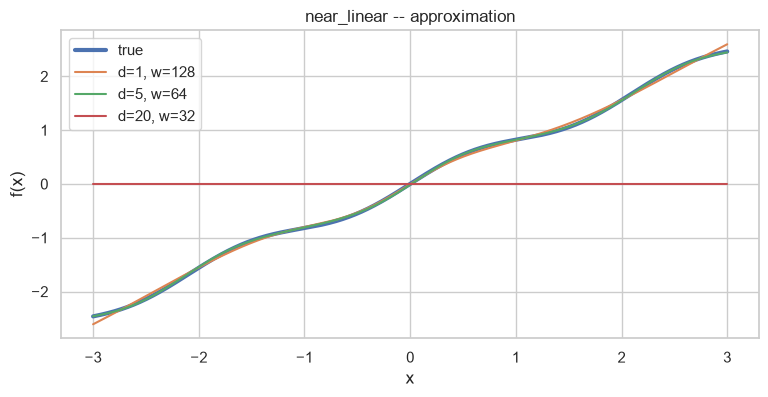

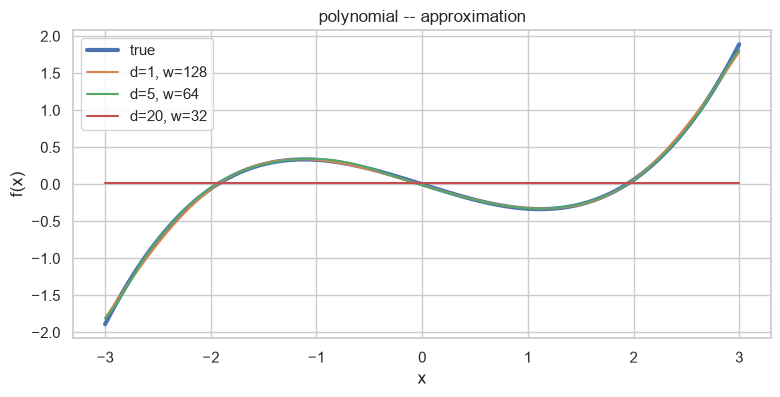

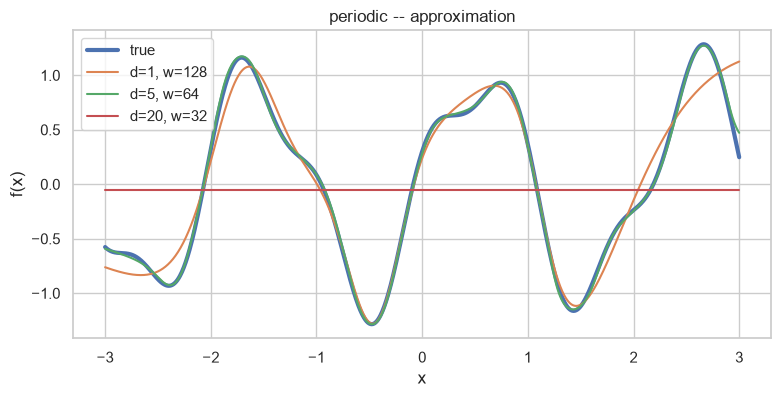

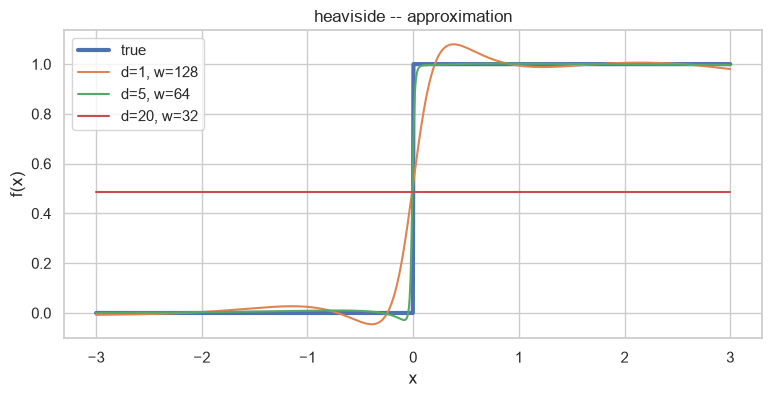

In [8]:
for function_name, function in FUNCTIONS.items():
    plt.figure(figsize=(9, 4))
    plt.plot(x_plot, function(x_plot), linewidth=3, label="true")
    for depth, width in COMPARE_CONFIGS:
        x_test, prediction = comparison_predictions[(function_name, depth, width)]
        plt.plot(x_test, prediction, label=f"d={depth}, w={width}")
    plt.title(f"{function_name} -- approximation")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.savefig(OUTPUT_DIR / f"synthetic_approximation_{function_name}.png", dpi=170, bbox_inches="tight")
    plt.show()


## Learning curve


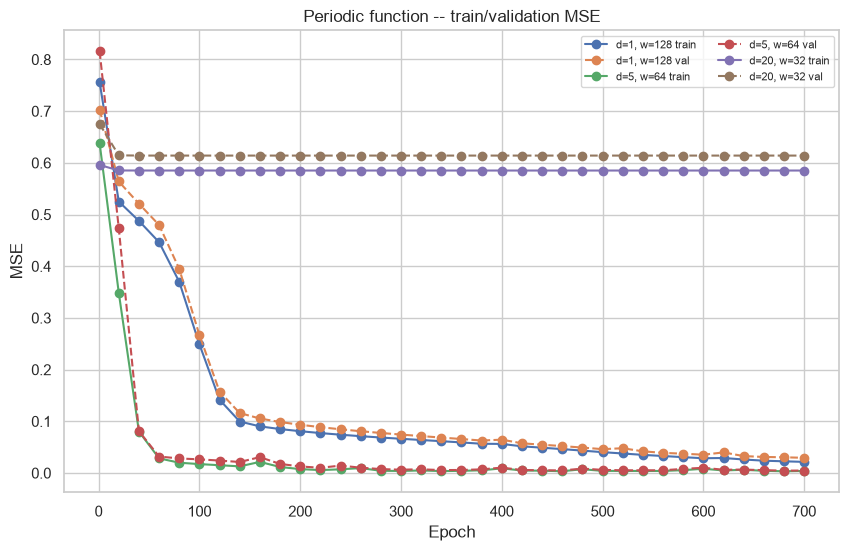

In [9]:
plt.figure(figsize=(10, 6))
for depth, width in COMPARE_CONFIGS:
    history = comparison_histories[("periodic", depth, width)]
    plt.plot(history.epoch, history.train_mse, marker="o", label=f"d={depth}, w={width} train")
    plt.plot(history.epoch, history.val_mse, marker="o", linestyle="--", label=f"d={depth}, w={width} val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Periodic function -- train/validation MSE")
plt.legend(ncol=2, fontsize=8)
plt.savefig(OUTPUT_DIR / "synthetic_learning_curve.png", dpi=170, bbox_inches="tight")
plt.show()


## Выводы

Смысл этого блока не в том, чтобы найти одну «лучшую MLP вообще»:

- почти линейная функция проверяет, что сложность действительно лишняя там, где задача простая;
- полином показывает гладкую нелинейность;
- периодическая функция дает более содержательный depth × width benchmark;
- Heaviside показывает качественно другой случай: сеть может сжать переход в узкую область, но непрерывная MLP не может идеально воспроизвести сам скачок в sup-норме.

Поэтому вывод о глубине надо делать вместе с шириной, числом параметров и learning curve. Очень глубокая сеть сама по себе ничего не гарантирует -- оптимизировать ее еще надо.
